In [1]:
import numpy as np
import cv2
import os
from astropy.io import fits
import astroalign as aa
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from astropy.stats import sigma_clipped_stats
import shutil

In [2]:
cd G:\Mon Drive\PhotoAstro\2025-08-02_20-15-49_plan_Mon_plan\05-observation-m51\01-images-initial\

G:\Mon Drive\PhotoAstro\2025-08-02_20-15-49_plan_Mon_plan\05-observation-m51\01-images-initial


In [3]:
ls

 Le volume dans le lecteur G s'appelle Google Drive
 Le num‚ro de s‚rie du volume est 1983-1116

 R‚pertoire de G:\Mon Drive\PhotoAstro\2025-08-02_20-15-49_plan_Mon_plan\05-observation-m51\01-images-initial

28/08/2025  01:32    <DIR>          .
05/08/2025  10:52    <DIR>          ..
02/08/2025  22:19        16ÿ591ÿ680 img-0001.fits
02/08/2025  22:19         2ÿ575ÿ726 img-0002-output.jpg
02/08/2025  22:20        16ÿ591ÿ680 img-0003.fits
02/08/2025  22:20        16ÿ591ÿ680 img-0004.fits
02/08/2025  22:20        16ÿ591ÿ680 img-0005.fits
02/08/2025  22:20         2ÿ428ÿ272 img-0005-output.jpg
02/08/2025  22:20        16ÿ591ÿ680 img-0006.fits
02/08/2025  22:20         1ÿ843ÿ664 img-0007-output.jpg
02/08/2025  22:20        16ÿ591ÿ680 img-0008.fits
02/08/2025  22:21         2ÿ277ÿ417 img-0008-output.jpg
02/08/2025  22:21        16ÿ591ÿ680 img-0009.fits
02/08/2025  22:21        16ÿ591ÿ680 img-0010.fits
02/08/2025  22:21        16ÿ591ÿ680 img-0011.fits
02/08/2025  22:21         2ÿ222ÿ298 img-0

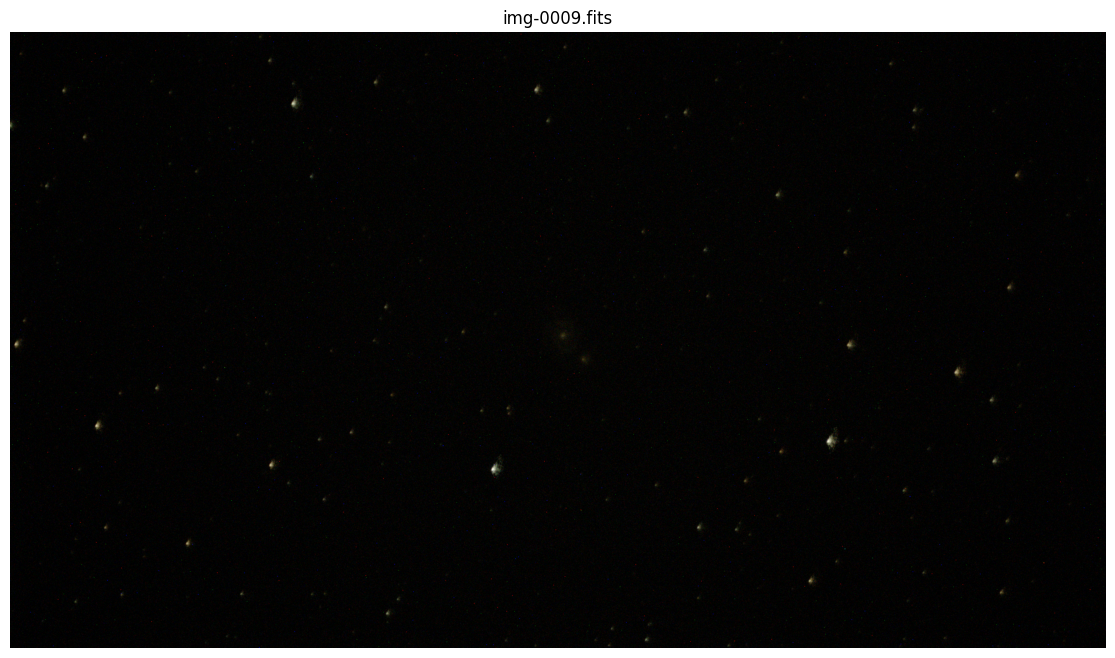

KeyboardInterrupt: Interrupted by user

In [4]:
### GOOD ONE

tri_image=True

def process_fits(filename):
    #fits_path = "img-0001.fits"   # si tu repars du raw Bayer, fais le débayer avant ce pipeline
    bayer_pattern = "GBRG"
    gain_db = 20          # gain en dB (ex: 6 dB ≈ x2)
    denoise_patch_kw = dict(patch_size=7, patch_distance=11, h_factor=1.0)  # NL-means params
    
    psf_sigma = 1.5               # pour PSF gaussienne si deconv activée
    asinh_scale = 10.0            # paramètre du asinh stretch pour affichage
    Soustraction_Fond = True
    Gain = True
    Denoise = False
    apply_deconv = False
    balance= False
    # -------------------------------------------
    
    # --- lecture (ici on suppose une image déjà débayerisée, sinon débayer avant) ---
    # Si tu as un RGB uint16 (H, W, 3)
    # Pour l'exemple, lis le fits et fais débayer si besoin (ici on suppose rgb_image prêt)
    # hdul = fits.open(fits_path); raw = hdul[0].data.astype(np.float32); hdul.close()
    # ... débayer avec cv2.cvtColor(raw_uint16, cv2.COLOR_BAYER_RGGB2RGB) ...
    # puis mettre le résultat dans rgb_image (uint16 ou float)
    
    # Pour illustrer je suppose rgb_image est déjà disponible ; sinon remplacer par ton débayer:
    # rgb_image = cv2.cvtColor(raw_uint16, cv2.COLOR_BAYER_RGGB2RGB)
    
    # ---------- Exemple: si tu pars du FITS Bayer (uint16) :
    hdul = fits.open(filename)
    raw = hdul[0].data.astype(np.float32)
    hdul.close()
    # normaliser sur la dynamique réelle :
    raw = raw - raw.min()
    raw /= raw.max()  # maintenant 0..1
    raw = np.clip(raw, 0, 1)
    # débayeriser en 8/16 bits (ici on convertit en uint16 pour OpenCV)
    raw_u16 = (raw * 65535).astype(np.uint16)
    rgb_u16 = cv2.cvtColor(raw_u16, cv2.COLOR_BAYER_GBRG2RGB)  # HxWx3 uint16
    
    # convertir en float 0..1 pour traitement linéaire
    rgb = rgb_u16.astype(np.float64) / 65535.0
    
    # ---------- 1) Estimation & soustraction du fond (par canal) ----------
    if Soustraction_Fond : 
        rgb_bg_sub = np.empty_like(rgb)
        for c in range(3):
            channel = rgb[:,:,c]
            mean, median, std = sigma_clipped_stats(channel, sigma=3.0, maxiters=5)
            bg = median
            # on soustrait le fond estimé, clamp au minimum 0
            rgb_bg_sub[:,:,c] = np.clip(channel - bg, 0.0, None)
    else : 
        rgb_bg_sub = rgb.copy()
    
    # ---------- 2) application d'un gain linéaire (depuis gain en dB) ----------
    if Gain : 
        gain_factor = 10 ** (gain_db / 20.0)  # conversion dB -> multiplicateur linéaire
        rgb_gain = rgb_bg_sub * gain_factor
        rgb_gain = np.clip(rgb_gain, 0.0, None)  # garder positif
    else : 
        rgb_gain = rgb_bg_sub.copy()
    
    # ---------- 3) Denoise : Non-Local Means (skimage) ----------
    # estimate noise-level per channel (optionnel)
    if Denoise : 
        sigma_est = np.mean([estimate_sigma(rgb_gain[:,:,c], channel_axis=None) for c in range(3)])
        
        h = denoise_patch_kw.get("h_factor", 1.0) * sigma_est
        # skimage expects image in [0,1]
        rgb_denoised = np.empty_like(rgb_gain)
        for c in range(3):
            channel = rgb_gain[:,:,c]
            den = denoise_nl_means(channel,
                                   patch_size=denoise_patch_kw['patch_size'],
                                   patch_distance=denoise_patch_kw['patch_distance'],
                                   h=h,
                                   fast_mode=True,
                                   preserve_range=True)
            rgb_denoised[:,:,c] = den
    else : 
        rgb_denoised = rgb_gain.copy()
    
    # ---------- 4) (optionnel) Déconvolution simple (Richardson-Lucy) ----------
    if apply_deconv:
        # créer PSF gaussienne normalisée
        size = int(8 * psf_sigma) | 1
        x = np.arange(size) - size//2
        xx, yy = np.meshgrid(x, x)
        psf = np.exp(-(xx**2 + yy**2) / (2*psf_sigma**2))
        psf /= psf.sum()
        for c in range(3):
            rgb_denoised[:,:,c] = richardson_lucy(rgb_denoised[:,:,c], psf, iterations=10)
    
    # ---------- 5) Stretch non-linéaire pour affichage (asinh recommended in astro) ----------
    def asinh_stretch(img, scale):
        # img in 0..inf (linear) ; scale controls roll-off
        return np.arcsinh(img * scale) / np.arcsinh(scale)

    rgb_stretched=rgb_denoised.copy()
    rgb_stretched[:,:,0] = asinh_stretch(rgb_denoised[:,:,0], asinh_scale)
    rgb_stretched[:,:,1] = asinh_stretch(rgb_denoised[:,:,1], asinh_scale)
    rgb_stretched[:,:,2] = asinh_stretch(rgb_denoised[:,:,2], asinh_scale)
    # normaliser 0..1 pour affichage
    rgb_out = rgb_stretched / np.max(rgb_stretched)
    rgb_out = np.clip(rgb_out, 0.0, 1.0)
    
    # ---------- 6) balance couleur légère si nécessaire ----------
    # simple white balance scaling by channel medians
    if balance : 
        medians = [np.median(rgb_out[:,:,c]) for c in range(3)]
        max_med = max(medians)
        gains = [max_med / m if m>0 else 1.0 for m in medians]
        for c in range(3):
            rgb_out[:,:,c] = np.clip(rgb_out[:,:,c] * gains[c], 0.0, 1.0)


    return rgb_out

# Liste des fichiers FITS
folder = "."
files = [f for f in os.listdir(folder) if f.lower().endswith(".fits")]
files.sort()  # tri alphabétique

# Prendre la première image comme référence
ref_image = process_fits(files[0])
stack = ref_image.astype(np.float32)
nbre_img=1
nbre_reject=0
nbre_illisible=0
# Alignement et stacking
for f in files[1:]:
    try : 
        img = process_fits(f)
    except : 
        print("Erreur lecture image "+str(f))
    if tri_image : 
        plt.figure(figsize=(15, 8))  # largeur=15 pouces, hauteur=8 pouces
        plt.imshow(img)
        plt.axis("off")
        plt.title(f)
        plt.show()     
        choix_ok = True
        while choix_ok : 
            keep = input("Garder cette image ? (y/n) : ").strip().lower()
            if keep == 'n':
                trash_dir = os.path.join(os.path.dirname(f), "trash")
                os.makedirs(trash_dir, exist_ok=True)  # Création si besoin
                shutil.move(f, os.path.join(trash_dir, os.path.basename(f)))
                nbre_reject+=1
                print(f"Image déplacée vers {trash_dir}")
                choix_ok=False
            elif keep=='y' : 
                choix_ok=False
                print("Image conservée ✅")

    clear_output(wait=True)            
    if keep=='y' :             
        try:
            aligned, footprint = aa.register(img, ref_image)
            stack += aligned.astype(np.float32)
            nbre_img+=1
            clear_output(wait=True)
            stack_inter = stack/nbre_img
            print(f)
            plt.figure(figsize=(15, 8))  # largeur=15 pouces, hauteur=8 pouces
            plt.imshow(stack_inter)
            plt.title("Stacked "+str(nbre_img))
            plt.axis("off")
            plt.show()

    
        except aa.MaxIterError:
            print("Alignement échoué pour"+f)

# Moyenne finale
stack /= nbre_img
stack_8bit = (stack * 255.).astype(np.uint8)

# Sauvegarde
cv2.imwrite("stacked.jpg", cv2.cvtColor(stack_8bit, cv2.COLOR_RGB2BGR))
stack_16bit = (stack * 65535).astype(np.uint16)
cv2.imwrite("stacked.tiff", cv2.cvtColor(stack_16bit, cv2.COLOR_RGB2BGR))

# Affichage
plt.imshow(stack)
plt.axis("off")
plt.title("Image stackée et alignée")
plt.show()

Max avant gamma : 0.9999799


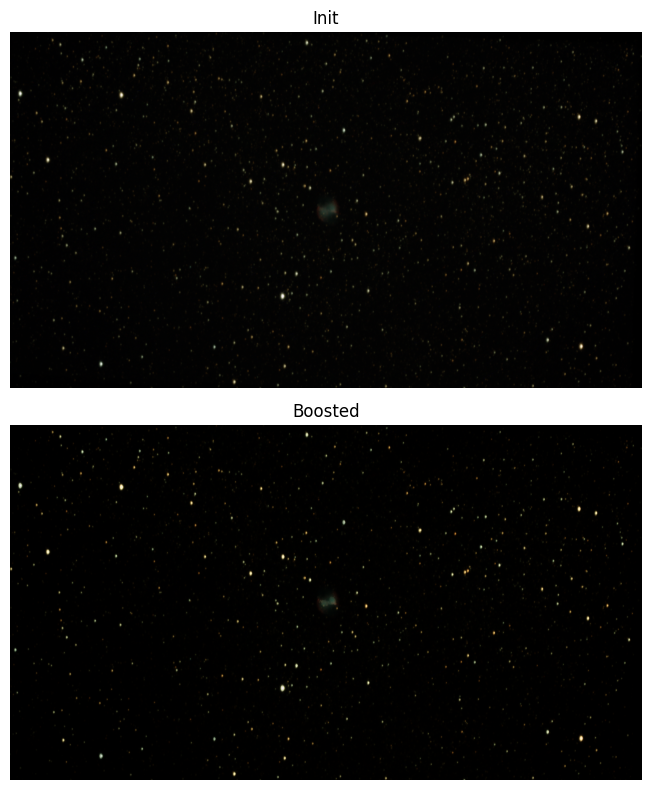

False

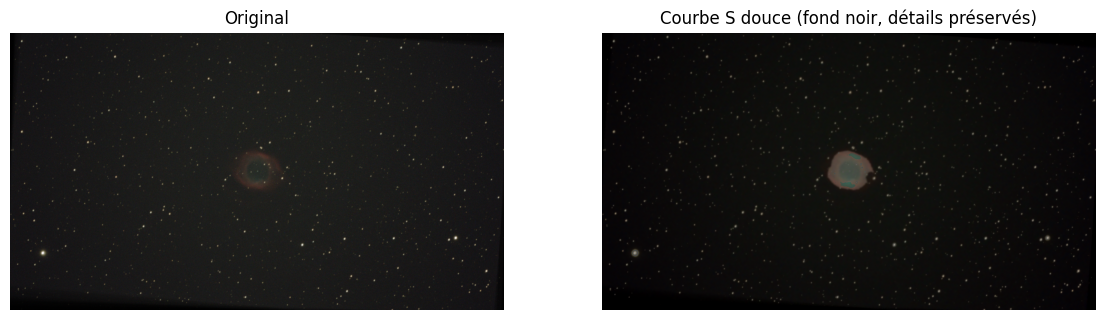

NameError: name 'estimate_sigma' is not defined

True

In [ ]:
img = stack.copy()
print("Max avant gamma :", np.max(img))
img_16bit = (img.astype(np.float32) * 65535).astype(np.uint16)
cv2.imwrite("OUT/image_stack.tiff", cv2.cvtColor(img_16bit, cv2.COLOR_RGB2BGR))

# Paramètre gamma : <1 éclaircit, >1 assombrit
gamma = 1.2
img_gamma = np.power(img, gamma)  # conserve valeurs entre 0 et 1

# Convertir en 0..255 uint8 pour OpenCV
img_gamma_8bit = np.clip(img_gamma * 255, 0, 255).astype(np.uint8)

# Convertir en HSV
hsv = cv2.cvtColor(img_gamma_8bit, cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv)

# Masque zones colorées pas trop sombres
mask = (s > 40) & (v > 30)

# Boost de luminosité sur les zones masquées
v_boosted = v.astype(np.float32)
v_boosted[mask] = np.clip(v_boosted[mask] * 1.6, 0, 255)
v_boosted = v_boosted.astype(np.uint8)

# Recombiner et repasser en RGB
hsv_boosted = cv2.merge([h, s, v_boosted])
img_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2RGB)

# Affichage
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].imshow(stack_8bit)
axes[0].set_title("Init")
axes[0].axis("off")

axes[1].imshow(img_boosted)
axes[1].set_title("Boosted")
axes[1].axis("off")

plt.tight_layout()
display(fig)
plt.close(fig)


# Sauvegarde en TIFF 16 bits
img_boosted_16bit = (img_boosted.astype(np.float32) / 255.0 * 65535).astype(np.uint16)
cv2.imwrite("OUT/image_boosted.tiff", cv2.cvtColor(img_boosted_16bit, cv2.COLOR_RGB2BGR))






# Lecture
img = cv2.imread("OUT/image_stack.tiff", cv2.IMREAD_UNCHANGED)


# Normalisation (0-1)
if img.dtype != np.float32:
    img = cv2.normalize(img.astype(np.float32), None, 0.0, 1.0, cv2.NORM_MINMAX)

# Réduction de bruit
img_denoised = cv2.fastNlMeansDenoisingColored((img*255).astype(np.uint8), None, 8, 8, 7, 21)
img_denoised = img_denoised.astype(np.float32) / 255.0

# Masque de luminance
gray = cv2.cvtColor((img_denoised*255).astype(np.uint8), cv2.COLOR_BGR2GRAY) / 255.0
mask = cv2.GaussianBlur((gray > 0.15).astype(np.float32), (0,0), 5)

# Fonction d'étirement personnalisée (courbe en S aplatie en haut)
def stretch_curve(x, mid=0.25, low_boost=1.5, high_compress=0.5):
    # boost les tons sombres, compresse les tons clairs
    return np.where(
        x < mid,
        x**(1/low_boost),
        mid + (x-mid) * high_compress
    )

stretched = stretch_curve(img_denoised)

# Appliquer fort sur nébuleuse, doux sur fond
result = img_denoised*(1-mask[:,:,None]) + stretched*mask[:,:,None]

# Assombrir légèrement le fond
result -= (1-mask[:,:,None]) * 0.05
result = np.clip(result, 0, 1)

# Boost saturation léger
hsv = cv2.cvtColor((result*255).astype(np.uint8), cv2.COLOR_BGR2HSV)
hsv[...,1] = np.clip(hsv[...,1] * 1.25, 0, 255)
final_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

# Affichage
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Courbe S douce (fond noir, détails préservés)")
plt.axis('off')
plt.show()